In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("adult.csv")

print(df.head())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

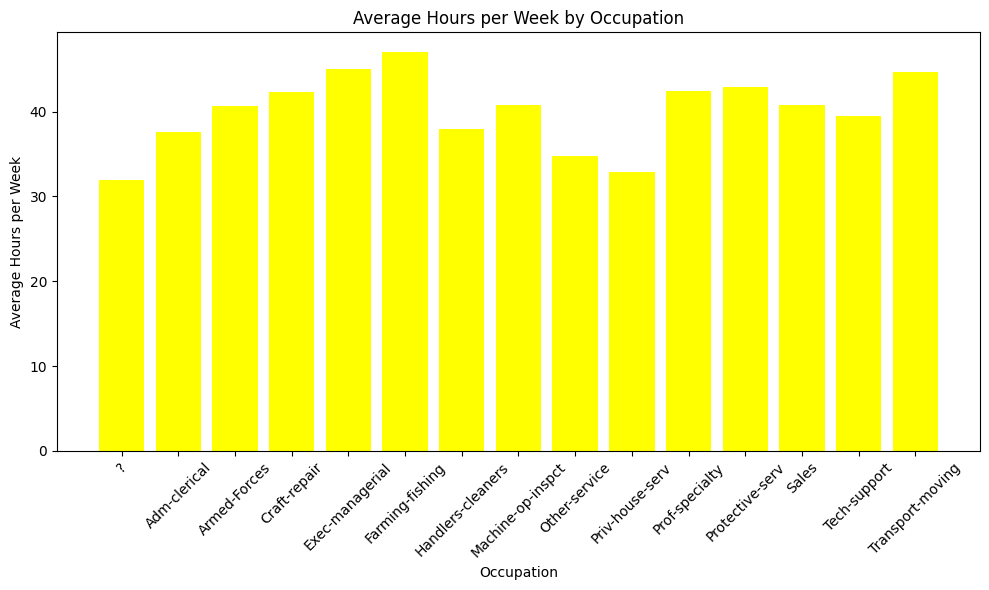

In [24]:
#task1

avg_hours = df.groupby("occupation")["hours.per.week"].mean()

plt.figure(figsize=(10, 6))
plt.bar(avg_hours.index, avg_hours.values,color="yellow")


plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours per Week by Occupation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


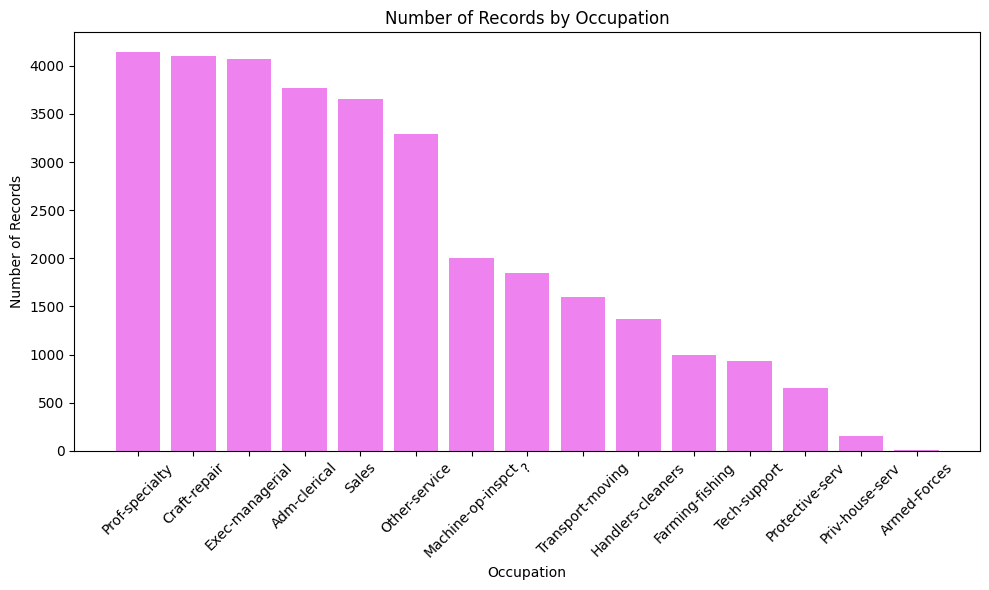

Most common occupation: Prof-specialty
Number of records: 4140


In [26]:

occupation_counts = df["occupation"].value_counts()

# Create count plot
plt.figure(figsize=(10, 6))
plt.bar(occupation_counts.index, occupation_counts.values, color="violet")

plt.xlabel("Occupation")
plt.ylabel("Number of Records")
plt.title("Number of Records by Occupation")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Most common occupation:", occupation_counts.idxmax())
print("Number of records:", occupation_counts.max())

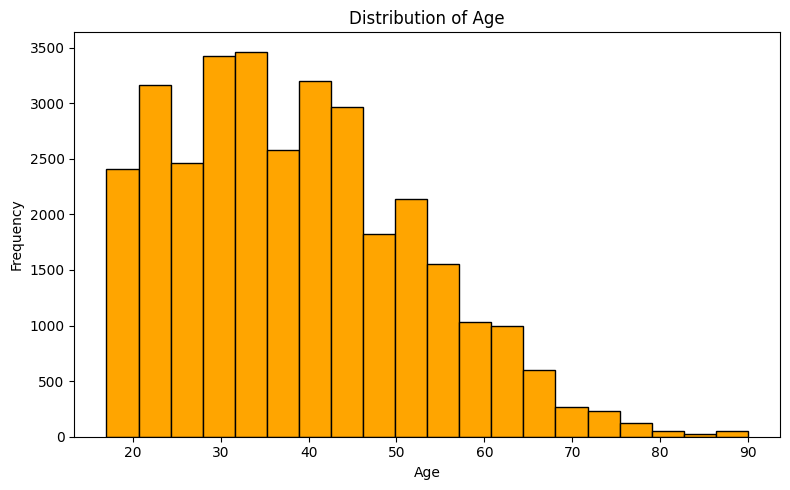

In [27]:
#task3

plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=20, edgecolor="black", color="orange")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")

plt.tight_layout()
plt.show()

its right skewed

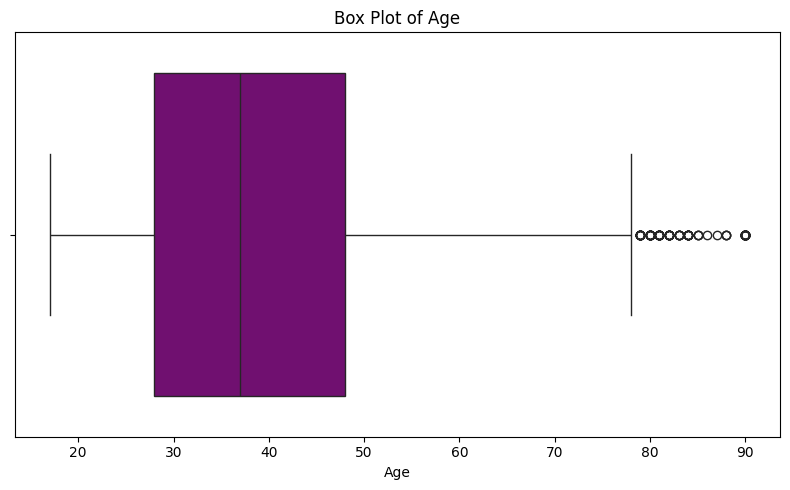

In [28]:
#task4
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["age"], color="purple")

plt.xlabel("Age")
plt.title("Box Plot of Age")

plt.tight_layout()
plt.show()


In [10]:
#task 5

Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)


IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["age"] < lower) | (df["age"] > upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))

Q1: 28.0
Q3: 48.0
IQR: 20.0
Lower bound: -2.0
Upper bound: 78.0
Number of outliers: 143


In Task 4, the box plot showed several outlier points beyond the upper whisker. In  5, IQR method identified 143 outliers, with the upper bound equal to 78. Therefore,  box plot is consistent with the IQR calculation, although the exact number of points is easier to determine using the IQR method.

In [12]:
#task 6
from scipy import stats

df["zscore"] = stats.zscore(df["age"])

# outliers
outliers_z = df[df["zscore"].abs() > 3]

print("Number of Z-score outliers:", len(outliers_z))

Number of Z-score outliers: 121


Answer: The Z-score method finds 121 outliers.
Comparison: No, they are not the same. IQR finds more outliers because the age column is right-skewed.

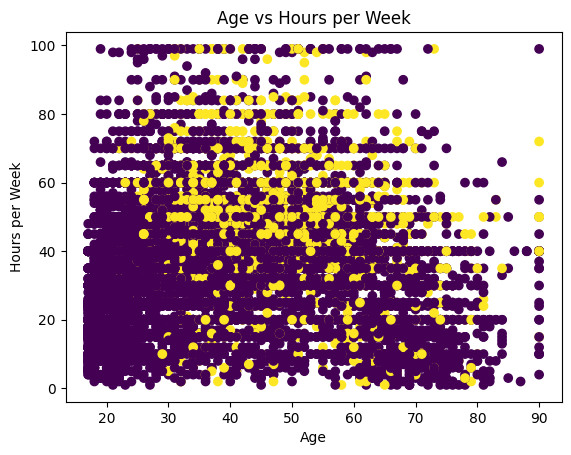

In [25]:
#task 7
plt.scatter(df["age"], df["hours.per.week"], c=df["income"].astype("category").cat.codes)

plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("Age vs Hours per Week")

plt.show()

There appears to be a weak positive relationship.

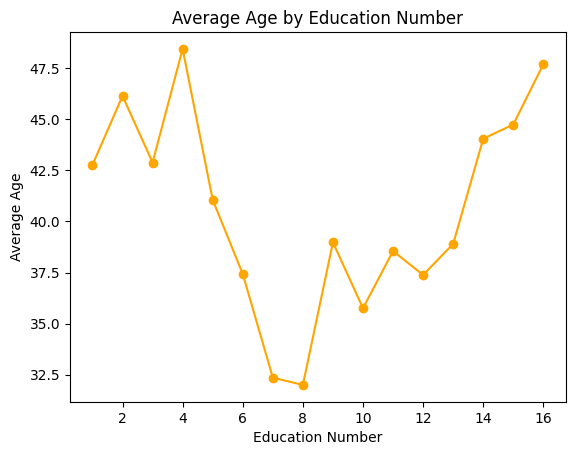

In [20]:
#task 8
average_age = df.groupby("education.num")["age"].mean()

plt.plot(average_age.index, average_age.values,
         marker="o", color="orange")

plt.xlabel("Education Number")
plt.ylabel("Average Age")
plt.title("Average Age by Education Number")

plt.show()

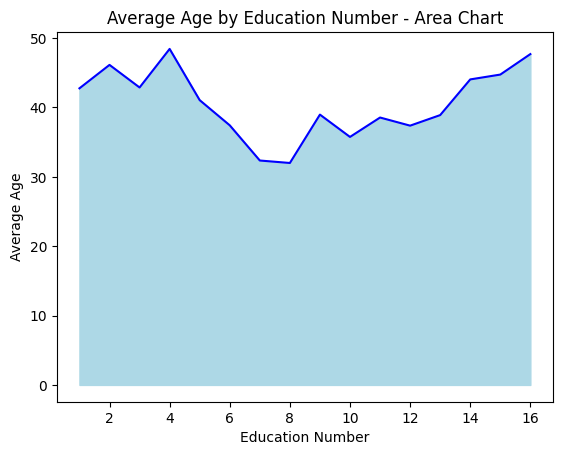

In [21]:
#area chart
plt.fill_between(average_age.index, average_age.values,
                 color="lightblue")

plt.plot(average_age.index, average_age.values,
         color="blue")

plt.xlabel("Education Number")
plt.ylabel("Average Age")
plt.title("Average Age by Education Number - Area Chart")

plt.show()

The line chart shows the trend more clearly, while the area chart makes the size of the values more noticeable.

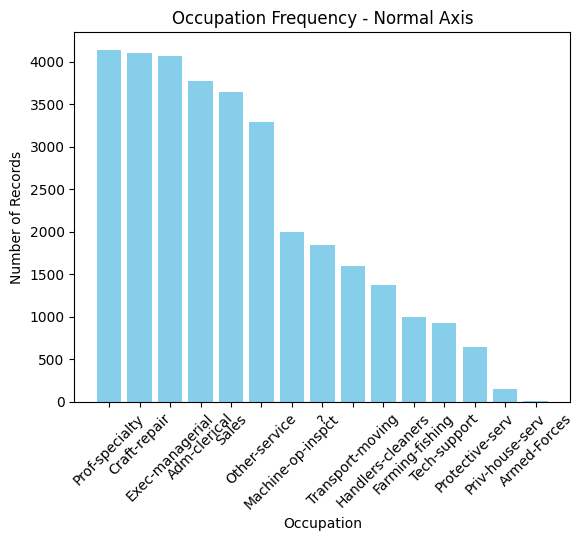

In [22]:
#task 9

#normla bar chart
counts = df["occupation"].value_counts()

plt.bar(counts.index, counts.values, color="skyblue")

plt.xlabel("Occupation")
plt.ylabel("Number of Records")
plt.title("Occupation Frequency - Normal Axis")
plt.xticks(rotation=45)

plt.ylim(0)

plt.show()

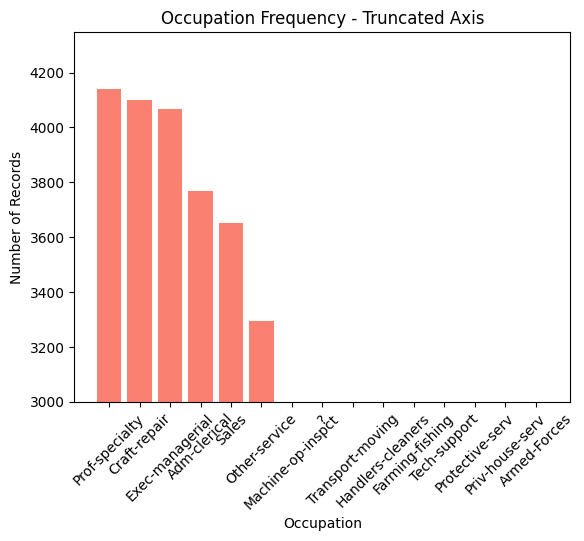

In [23]:
#truncate axis
plt.bar(counts.index, counts.values, color="salmon")

plt.xlabel("Occupation")
plt.ylabel("Number of Records")
plt.title("Occupation Frequency - Truncated Axis")
plt.xticks(rotation=45)

plt.ylim(3000)

plt.show()

The truncated axis makes the differences between occupations look much bigger than they really are. Starting the y-axis at zero gives a more honest visual comparison.